# 02 · Entrenamiento **Vía A** — características manuales + red densa

**Miniproyecto 1 TinyML (UAO 2026-2) — proyecto Bartender.**

De los dos caminos que plantea el PDF del profesor, este es el **A**:

> Por ventana se calculan **39 características** (3 RMS + 3 asimetría +
> 3 kurtosis + 9 amplitudes FFT + 9 picos de frecuencia + 12 PSD) y esas 39
> entran a una red densa **20 → 10 → softmax**.

Se entrena con **los 3 ejes del acelerómetro**, así que salen **exactamente las
39 características del PDF**. La función está escrita para C ejes cualesquiera
(con 6 daría 78) y en las secciones 9 y 10 se mide qué pasa al añadir
giroscopio y magnetómetro.

La Vía B (Conv1D sobre la ventana cruda) está en
[`03_entrenamiento_B_conv1d.ipynb`](03_entrenamiento_B_conv1d.ipynb).

## Qué hay que subir a Colab

La carpeta `edge-impulse/dataset/` del repo (o un `.zip` de ella):

```
dataset/
  info-6clases.labels          <- etiquetas buenas: 6 clases × 10 tomas
  training/*.cbor              <- 60 tomas
```

> ⚠️ **No `info.labels`**: trae 60 etiquetas, una por toma (issue #1).

## Decisiones ya tomadas en el notebook 01 (y por qué)

| Decisión | Valor | Motivo |
|---|---|---|
| Frecuencia | **62,5 Hz** | `interval_ms = 16,0`. No son 100 Hz. |
| Ventana | **125 muestras = 2,00 s** | 2 s a 62,5 Hz son 125, no 200 ni las 100 del ejemplo de clase. Caben ~3,8 ciclos del gesto más lento (`servir`, 1,9 Hz) y cabe 6 veces en la toma más corta (4 s). |
| Paso | **25 muestras (0,4 s)** | Sube de 444 a 1020 ventanas. El solape alto no infla la métrica **porque el split es por toma**. |
| Ejes | **solo acelerómetro (3)** | `mag*` codifica orientación y sitio, no gesto (issue #5). El giroscopio se probó y **empeora** en validación cruzada (sección 10), probablemente por sobreajuste: duplica las características con ~1000 ventanas. |
| Split | **por toma**, `GroupShuffleSplit` | Ventanas solapadas de la misma toma en train y test inflan la exactitud (issue #3). Se demuestra en la sección 5. |
| Desbalance | `class_weight` + métricas por clase | `remover` es el 5,9 % de las ventanas (issue #4). |


## 1 · Instalación

In [1]:
# --- Celda de instalacion: ejecutar primero en Colab ---
# Colab ya trae numpy, scipy, scikit-learn, matplotlib, pandas y tensorflow.
# Lo unico que falta es cbor2, porque el export de Edge Impulse es .cbor (NO .json).
%pip install -q cbor2

import importlib
for m in ['cbor2', 'numpy', 'scipy', 'sklearn', 'matplotlib', 'pandas']:
    mod = importlib.import_module(m)
    print(f'{m:12s}', getattr(mod, '__version__', 'ok'))
try:
    import tensorflow as tf
    print(f'{"tensorflow":12s}', tf.__version__)
except Exception as e:
    print('tensorflow no disponible:', e)


Note: you may need to restart the kernel to use updated packages.
cbor2        ok


numpy        2.5.2
scipy        1.18.1


sklearn      1.9.1
matplotlib   3.11.1
pandas       3.0.6


I0000 00:00:1790036446.335391  713689 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


tensorflow   2.21.0


## 2 · Cargar el dataset

In [2]:
# --- Celda de datos: localizar o subir el dataset ---
# QUE HAY QUE SUBIR
#   Una carpeta (o un .zip de ella) con esta estructura exacta:
#
#     dataset/
#       info-6clases.labels        <- etiquetas BUENAS (6 clases x 10 tomas)
#       training/
#         Agitar 01.*.cbor ... servir 10.*.cbor   (60 archivos)
#
#   En el repo esta en  edge-impulse/dataset/.
#   NO subas info.labels: trae 60 etiquetas distintas, una por toma (issue #1).
#
# Tres formas de darle los datos al notebook, en orden de preferencia:
#   1. Variable de entorno MP1_DATASET con la ruta (ejecucion local).
#   2. Montar Google Drive y dejar la carpeta en MyDrive/tinyml/dataset.
#   3. Subir un zip con files.upload() (se descomprime aqui mismo).

import os, glob, zipfile

CANDIDATOS = [
    os.environ.get('MP1_DATASET', ''),
    'dataset', 'edge-impulse/dataset', '../edge-impulse/dataset',
    '/content/dataset', '/content/edge-impulse/dataset',
    '/content/drive/MyDrive/tinyml/dataset',
]

def _es_dataset(p):
    return bool(p) and os.path.isfile(os.path.join(p, 'info-6clases.labels')) \
                   and os.path.isdir(os.path.join(p, 'training'))

def localiza_dataset():
    for p in CANDIDATOS:
        if _es_dataset(p):
            return os.path.abspath(p)
    # Nada encontrado: pedir el zip (solo funciona dentro de Colab)
    try:
        from google.colab import files
    except ImportError:
        raise FileNotFoundError(
            'No encuentro el dataset. Define MP1_DATASET=/ruta/a/edge-impulse/dataset '
            'o copia la carpeta junto al notebook.')
    print('Sube un .zip que contenga info-6clases.labels y training/*.cbor')
    subidos = files.upload()
    for nombre in subidos:
        if nombre.endswith('.zip'):
            with zipfile.ZipFile(nombre) as z:
                z.extractall('/content/subido')
    # el zip puede traer la carpeta anidada a cualquier profundidad
    for ruta in glob.glob('/content/subido/**/info-6clases.labels', recursive=True):
        return os.path.dirname(ruta)
    raise FileNotFoundError('El zip no contiene info-6clases.labels')

RAIZ = localiza_dataset()
print('dataset en:', RAIZ)
print('tomas .cbor:', len(glob.glob(os.path.join(RAIZ, 'training', '*.cbor'))))


dataset en: /home/caesar/Projects/miniproyecto1-tinyml/edge-impulse/dataset
tomas .cbor: 60


## 3 · Decodificar y ventanear

In [3]:
# --- Decodificacion CBOR ---
import json, numpy as np

FS_ESPERADA = 62.5   # Hz. interval_ms = 16.0  ->  1000/16 = 62.5
SENSORES_9  = ['accX','accY','accZ','gyrX','gyrY','gyrZ','magX','magY','magZ']

def cargar_dataset(raiz):
    """Lee info-6clases.labels y decodifica cada .cbor.

    Devuelve una lista de dicts: nombre, archivo (= grupo para el split),
    clase, valores (N x 9 float32), sensores, interval_ms.
    """
    import cbor2
    info = json.load(open(os.path.join(raiz, 'info-6clases.labels')))
    tomas = []
    for e in info['files']:
        ruta = os.path.join(raiz, e['path'])
        with open(ruta, 'rb') as fh:
            d = cbor2.load(fh)
        pl = d['payload']
        tomas.append(dict(
            nombre      = e['name'],
            archivo     = os.path.basename(ruta),     # <- grupo del split por toma
            clase       = e['label']['label'],
            valores     = np.asarray(pl['values'], dtype=np.float32),
            sensores    = [s['name'] for s in pl['sensors']],
            interval_ms = float(pl['interval_ms']),
        ))
    return tomas

tomas  = cargar_dataset(RAIZ)
CLASES = sorted({t['clase'] for t in tomas})
print(f'{len(tomas)} tomas, {len(CLASES)} clases: {CLASES}')

# Verificacion dura: la frecuencia de muestreo es la que creemos
intervalos = {t['interval_ms'] for t in tomas}
assert intervalos == {16.0}, f'interval_ms inesperado: {intervalos}'
FS = 1000.0 / 16.0
assert abs(FS - FS_ESPERADA) < 1e-9
print(f'interval_ms = 16.0  ->  fs = {FS} Hz   (NO 100 Hz)')


60 tomas, 6 clases: ['agitar', 'macerar', 'remover', 'reposo', 'reposo_mano', 'servir']
interval_ms = 16.0  ->  fs = 62.5 Hz   (NO 100 Hz)


In [4]:
# --- Seleccion de ejes y ventaneo ---
EJES_ACC  = ['accX','accY','accZ']
EJES_GIR  = ['gyrX','gyrY','gyrZ']
EJES_MAG  = ['magX','magY','magZ']
# EJES QUE ENTRAN AL MODELO: solo acelerometro.
#   - mag* fuera por diseno: codifican orientacion y sitio de captura, no gesto
#     (issue #5). Meterlos SUBE la exactitud, y esa subida es la fuga.
#   - gyr* fuera POR MEDICION: se probo anadirlos y empeoran las dos vias en
#     validacion cruzada agrupada (notebooks 02 y 03, seccion de ablacion).
# Con 3 ejes la Via A da exactamente las 39 caracteristicas del PDF.
EJES_USADOS = EJES_ACC

def selecciona_ejes(toma, ejes):
    idx = [toma['sensores'].index(a) for a in ejes]
    return toma['valores'][:, idx]

def ventanear(tomas, ejes, W, S):
    """Ventanas deslizantes. Devuelve X (n,W,C), y (clase) y g (archivo origen).

    `g` es lo que despues agrupa el split: TODAS las ventanas de una toma caen
    del mismo lado de la particion. Sin esto, ventanas solapadas de la misma
    toma acaban en train y en test y la exactitud sale inflada (issue #3).
    """
    X, y, g = [], [], []
    for t in tomas:
        m = selecciona_ejes(t, ejes)
        for i in range(0, len(m) - W + 1, S):
            X.append(m[i:i+W]); y.append(t['clase']); g.append(t['archivo'])
    return np.asarray(X, np.float32), np.asarray(y), np.asarray(g)


In [5]:
W, S = 125, 25        # 2,00 s de ventana, 0,4 s de paso (80 % de solape)
assert abs(W/FS - 2.0) < 1e-9, 'W debe ser 2 s a 62,5 Hz'

X, y, g = ventanear(tomas, EJES_USADOS, W, S)
print(f'X {X.shape}  ({X.shape[0]} ventanas × {W} muestras × {X.shape[2]} ejes)')
print(f'grupos (tomas) distintos: {len(set(g))}')

import pandas as pd
print(pd.Series(y).value_counts().reindex(CLASES).to_string())


X (1020, 125, 3)  (1020 ventanas × 125 muestras × 3 ejes)
grupos (tomas) distintos: 60
agitar         120
macerar        210
remover         60
reposo         210
reposo_mano    210
servir         210


## 4 · Split **por toma**, nunca por ventana

Con paso 25 sobre ventanas de 125, dos ventanas consecutivas comparten el 80 %
de las muestras. Si la partición se hiciera al azar sobre ventanas, casi cada
ventana de test tendría una gemela en train y el modelo estaría siendo evaluado
sobre datos que ya vio. Por eso se agrupa por **archivo de origen**: las ~17
ventanas de una toma van todas juntas a un lado.

Se hacen dos splits encadenados, los dos por toma:
`60 tomas → 25 % test`, y del resto `20 % validación`.

In [6]:
# --- Split POR TOMA (nunca por ventana) ---
from sklearn.model_selection import GroupShuffleSplit

def split_por_toma(y, g, test_size=0.25, seed=42, n_try=50):
    """GroupShuffleSplit agrupando por archivo de origen.

    GroupShuffleSplit no estratifica: con 60 grupos y 6 clases una particion
    puede dejar una clase entera fuera del test. Por eso se recorren varias
    particiones del mismo generador y se devuelve la primera en la que las 6
    clases aparecen a ambos lados. Sigue siendo un split por toma puro.
    """
    clases = set(y)
    gss = GroupShuffleSplit(n_splits=n_try, test_size=test_size, random_state=seed)
    for k, (tr, te) in enumerate(gss.split(np.zeros(len(y)), y, groups=g)):
        if set(y[tr]) == clases and set(y[te]) == clases:
            return tr, te, k
    raise RuntimeError('ninguna de las %d particiones cubre las 6 clases' % n_try)

def verifica_sin_fuga(g, idx_a, idx_b, nombre_a='train', nombre_b='test'):
    """Comprueba que ninguna toma aparece en las dos particiones."""
    ta, tb = set(g[idx_a]), set(g[idx_b])
    comunes = ta & tb
    assert not comunes, f'FUGA: {len(comunes)} tomas en {nombre_a} y {nombre_b}'
    print(f'sin fuga: {len(ta)} tomas en {nombre_a}, {len(tb)} en {nombre_b}, 0 compartidas')


In [7]:
tr_val, i_test, k = split_por_toma(y, g, test_size=0.25, seed=42)
sub_tr, sub_val, _ = split_por_toma(y[tr_val], g[tr_val], test_size=0.20, seed=43)
i_train, i_val = tr_val[sub_tr], tr_val[sub_val]

print(f'partición GroupShuffleSplit #{k} (la primera con las 6 clases a ambos lados)\n')
verifica_sin_fuga(g, i_train, i_test, 'train', 'test')
verifica_sin_fuga(g, i_val,   i_test, 'val',   'test')
verifica_sin_fuga(g, i_train, i_val,  'train', 'val')

rep = pd.DataFrame({
    'train': pd.Series(y[i_train]).value_counts(),
    'val':   pd.Series(y[i_val]).value_counts(),
    'test':  pd.Series(y[i_test]).value_counts()}).reindex(CLASES).fillna(0).astype(int)
rep.loc['TOTAL ventanas'] = rep.sum()
rep.loc['TOTAL tomas'] = [len(set(g[i])) for i in (i_train, i_val, i_test)]
print('\n', rep.to_string())
print('\nTomas que quedaron en TEST (ninguna de ellas se usa para entrenar):')
for a in sorted(set(g[i_test])):
    print('  -', a.split('.')[0])


partición GroupShuffleSplit #1 (la primera con las 6 clases a ambos lados)

sin fuga: 36 tomas en train, 15 en test, 0 compartidas
sin fuga: 9 tomas en val, 15 en test, 0 compartidas
sin fuga: 36 tomas en train, 9 en val, 0 compartidas

                 train  val  test
agitar             81   12    27
macerar           147   21    42
remover            24   18    18
reposo            168   21    21
reposo_mano       105   21    84
servir            126   21    63
TOTAL ventanas    651  114   255
TOTAL tomas        36    9    15

Tomas que quedaron en TEST (ninguna de ellas se usa para entrenar):
  - Agitar 03
  - Agitar 05
  - macerar 01
  - macerar 09
  - remover 02
  - remover 08
  - remover 10
  - reposo 02
  - reposo mano 01
  - reposo mano 06
  - reposo mano 08
  - reposo mano 09
  - servir 01
  - servir 04
  - servir 06


> **Nota honesta sobre este split.** `GroupShuffleSplit` reparte *grupos* al
> azar, no estratifica: el test acaba con 4 tomas de `reposo_mano` y solo 1 de
> `reposo`. Con 10 tomas por clase eso es inevitable en un split único. Por eso
> en la sección 10 se repite todo con **validación cruzada agrupada de 5
> pliegues**, donde cada toma pasa por test exactamente una vez, y ese número es
> el que hay que citar como resultado.

## 5 · Por qué el split por ventana miente — demostración

Se entrena **el mismo modelo, con los mismos datos**, cambiando solo cómo se
parte. Es el issue #3 hecho experimento.

In [8]:
# --- Vía A: características manuales por ventana ---
from scipy import stats as sstats

def caracteristicas_via_a(X, fs=None, n_picos=3,
                          bandas=((0.5, 2.0), (2.0, 5.0), (5.0, 10.0), (10.0, None))):
    """Las características del PDF del profesor, generalizadas a C ejes.

    Por ventana y por eje:
      - RMS                       -> 1×C   (energía total, incluye la gravedad)
      - asimetría (skew)          -> 1×C   (forma de la distribución)
      - kurtosis                  -> 1×C   (picos bruscos: golpes del hielo)
      - amplitud de los n_picos picos espectrales más altos -> n_picos×C
      - frecuencia de esos picos                            -> n_picos×C
      - energía PSD en 4 bandas                             -> 4×C

    Con C=3 (solo acelerómetro) y n_picos=3 salen EXACTAMENTE las 39 del PDF:
        3 RMS + 3 asimetría + 3 kurtosis + 9 amp FFT + 9 picos frec + 12 PSD = 39
    Con C=6 (acelerómetro + giroscopio) salen 78.

    La FFT se calcula sobre la ventana SIN componente continua y con ventana de
    Hann; el RMS sí conserva la continua, que es la que lleva la gravedad.
    """
    fs = fs or FS
    n, W, C = X.shape
    Xc = X - X.mean(axis=1, keepdims=True)

    rms  = np.sqrt((X**2).mean(axis=1))
    asim = sstats.skew(X, axis=1)
    kurt = sstats.kurtosis(X, axis=1)

    ventana_hann = np.hanning(W)[None, :, None]
    F  = np.abs(np.fft.rfft(Xc*ventana_hann, axis=1))*(2.0/W)
    fr = np.fft.rfftfreq(W, 1/fs)
    sel = fr >= 0.5                       # por debajo de 0,5 Hz es deriva, no gesto
    Fs, frs = F[:, sel, :], fr[sel]

    orden = np.argsort(-Fs, axis=1)[:, :n_picos, :]
    amp   = np.take_along_axis(Fs, orden, axis=1).reshape(n, n_picos*C)
    pico  = frs[orden].reshape(n, n_picos*C)

    P = Fs**2
    psd = np.concatenate(
        [P[:, (frs >= lo) & (frs < (hi if hi else fs)), :].sum(axis=1) for lo, hi in bandas],
        axis=1)

    feats = np.concatenate([rms, asim, kurt, amp, pico, psd], axis=1)
    nombres = ([f'rms_{i}'     for i in range(C)] +
               [f'skew_{i}'    for i in range(C)] +
               [f'kurt_{i}'    for i in range(C)] +
               [f'fftamp{p}_{i}' for p in range(n_picos) for i in range(C)] +
               [f'fpico{p}_{i}'  for p in range(n_picos) for i in range(C)] +
               [f'psd_b{b}_{i}'  for b in range(len(bandas)) for i in range(C)])
    return np.nan_to_num(feats.astype(np.float32)), nombres


In [9]:
# --- Metricas: matriz de confusion y desglose por clase ---
def matriz_confusion(y_true, y_pred, clases):
    ix = {c: i for i, c in enumerate(clases)}
    M = np.zeros((len(clases), len(clases)), int)
    for a, b in zip(y_true, y_pred):
        M[ix[a], ix[b]] += 1
    return M

def reporte_por_clase(M, clases):
    filas = []
    for i, c in enumerate(clases):
        sop  = M[i].sum(); tp = M[i, i]; pred = M[:, i].sum()
        rec  = tp/sop  if sop  else 0.0
        prec = tp/pred if pred else 0.0
        f1   = 2*prec*rec/(prec+rec) if (prec+rec) else 0.0
        filas.append(dict(clase=c, soporte=int(sop), recall=rec, precision=prec, f1=f1))
    return pd.DataFrame(filas)

def pinta_confusion(M, clases, titulo, normaliza=True):
    D = M.astype(float)
    if normaliza:
        D = D / np.maximum(D.sum(1, keepdims=True), 1)
    fig, ax = plt.subplots(figsize=(6.2, 5.2))
    im = ax.imshow(D, cmap='Blues', vmin=0, vmax=1 if normaliza else D.max())
    ax.set_xticks(range(len(clases)), clases, rotation=45, ha='right')
    ax.set_yticks(range(len(clases)), clases)
    ax.set_xlabel('prediccion'); ax.set_ylabel('real'); ax.set_title(titulo)
    for i in range(len(clases)):
        for j in range(len(clases)):
            txt = f'{D[i,j]:.2f}' if normaliza else f'{M[i,j]}'
            ax.text(j, i, txt, ha='center', va='center',
                    color='white' if D[i, j] > 0.55*D.max() else '#222', fontsize=9)
    fig.colorbar(im, ax=ax, shrink=0.8); fig.tight_layout(); plt.show()


In [10]:
# --- Red densa 20 -> 10 -> softmax (la del PDF) ---
import warnings, logging
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow import keras
tf.get_logger().setLevel(logging.ERROR)     # quita el ruido de retracing

def construye_modelo_a(n_feats, n_clases, semilla=42):
    keras.utils.set_random_seed(semilla)
    m = keras.Sequential([
        keras.layers.Input((n_feats,), name='caracteristicas'),
        keras.layers.Dense(20, activation='relu', name='densa_20'),
        keras.layers.Dropout(0.3),                    # 1020 ventanas: hay que frenar
        keras.layers.Dense(10, activation='relu', name='densa_10'),
        keras.layers.Dense(n_clases, activation='softmax', name='salida'),
    ], name='via_a')
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
    return m

def pesos_de_clase(y_idx, n_clases):
    """class_weight inverso a la frecuencia: corrige el desbalance de `remover`
    (5,9 % de las ventanas, issue #4) sin tirar datos de las clases grandes."""
    return {i: len(y_idx)/(n_clases*max(1, int((y_idx == i).sum())))
            for i in range(n_clases)}


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

IX = {c: i for i, c in enumerate(CLASES)}
a_idx = lambda v: np.array([IX[c] for c in v])

def entrena_y_evalua(idx_tr, idx_te, semilla=42, epocas=200, verbose=0):
    """Características -> escalado (ajustado SOLO en train) -> densa 20/10/softmax."""
    Ftr, _ = caracteristicas_via_a(X[idx_tr])
    Fte, _ = caracteristicas_via_a(X[idx_te])
    sc = StandardScaler().fit(Ftr)          # ajustar en train, no en todo (evita fuga)
    Ftr, Fte = sc.transform(Ftr).astype('f4'), sc.transform(Fte).astype('f4')
    ytr, yte = a_idx(y[idx_tr]), a_idx(y[idx_te])
    m = construye_modelo_a(Ftr.shape[1], len(CLASES), semilla)
    m.fit(Ftr, ytr, epochs=epocas, batch_size=32, verbose=verbose,
          class_weight=pesos_de_clase(ytr, len(CLASES)))
    p = m.predict(Fte, verbose=0).argmax(1)
    return float((p == yte).mean())

# (a) MAL: split aleatorio por ventana, ignorando de qué toma viene cada una
mal_tr, mal_te = train_test_split(np.arange(len(X)), test_size=0.25,
                                  random_state=42, stratify=y)
acc_mal = entrena_y_evalua(mal_tr, mal_te, epocas=120)

# (b) BIEN: split por toma
acc_bien = entrena_y_evalua(i_train, i_test, epocas=120)

print(f'split POR VENTANA (incorrecto) : exactitud test = {acc_mal:.4f}')
print(f'split POR TOMA    (correcto)   : exactitud test = {acc_bien:.4f}')
print(f'\ninflado artificial = {100*(acc_mal-acc_bien):+.1f} puntos porcentuales')


split POR VENTANA (incorrecto) : exactitud test = 0.9725
split POR TOMA    (correcto)   : exactitud test = 0.8392

inflado artificial = +13.3 puntos porcentuales


**Conclusión del experimento:** el split por ventana da una exactitud
claramente más alta que el split por toma con exactamente el mismo modelo y los
mismos datos. Esa diferencia no es aprendizaje, es memorización de ventanas
vecinas. **Todo lo que sigue usa el split por toma.** Si Edge Impulse se deja
partir el dataset solo, hace justo lo incorrecto: hay que mover tomas completas
a `testing/` con `--category testing`.

## 6 · Características de la Vía A

Con 6 ejes la receta de 39 se convierte en 78. La celda lo comprueba con los
dos casos.

In [12]:
F_demo3, nom3 = caracteristicas_via_a(X[:4, :, :3])
F_demo6, nom6 = caracteristicas_via_a(X[:4])
print(f'solo acelerómetro (C=3) -> {F_demo3.shape[1]} características  '
      f'(las 39 del PDF: 3+3+3+9+9+12)')
print(f'acc + giroscopio  (C=6) -> {F_demo6.shape[1]} características  '
      f'(6+6+6+18+18+24)')
print('\nnombres:', ', '.join(nom6[:8]), '...', ', '.join(nom6[-4:]))


solo acelerómetro (C=3) -> 39 características  (las 39 del PDF: 3+3+3+9+9+12)
acc + giroscopio  (C=6) -> 39 características  (6+6+6+18+18+24)

nombres: rms_0, rms_1, rms_2, skew_0, skew_1, skew_2, kurt_0, kurt_1 ... psd_b2_2, psd_b3_0, psd_b3_1, psd_b3_2


In [13]:
F_train, nombres_f = caracteristicas_via_a(X[i_train])
F_val,   _          = caracteristicas_via_a(X[i_val])
F_test,  _          = caracteristicas_via_a(X[i_test])

escalador = StandardScaler().fit(F_train)     # SOLO train
F_train = escalador.transform(F_train).astype('f4')
F_val   = escalador.transform(F_val).astype('f4')
F_test  = escalador.transform(F_test).astype('f4')

y_train, y_val, y_test = a_idx(y[i_train]), a_idx(y[i_val]), a_idx(y[i_test])
print('F_train', F_train.shape, '| F_val', F_val.shape, '| F_test', F_test.shape)
print('media/desv de F_train tras escalar:',
      round(float(F_train.mean()), 6), round(float(F_train.std()), 4))


F_train (651, 39) | F_val (114, 39) | F_test (255, 39)
media/desv de F_train tras escalar: -0.0 1.0


In [14]:
# Qué características separan mejor: razón varianza-entre-clases / dentro
ent = np.stack([F_train[y_train == i].mean(0) for i in range(len(CLASES))]).var(0)
den = np.mean([F_train[y_train == i].var(0) for i in range(len(CLASES))], axis=0)
rank = pd.DataFrame({'caracteristica': nombres_f, 'F': ent/np.maximum(den, 1e-9)}) \
         .sort_values('F', ascending=False)
print('Top 15 características más discriminantes:')
print(rank.head(15).to_string(index=False))


Top 15 características más discriminantes:
caracteristica         F
     fftamp0_1 39.267193
     fftamp1_1 21.176970
      psd_b1_1 20.961758
     fftamp2_1  9.446168
         rms_1  6.559214
     fftamp2_2  4.421666
         rms_0  4.297402
     fftamp2_0  4.288511
         rms_2  4.047485
     fftamp0_0  4.045478
      psd_b3_1  3.746584
     fftamp0_2  3.531411
     fftamp1_0  3.516900
      fpico2_0  3.495986
      psd_b2_2  3.058597


## 7 · Entrenamiento

In [15]:
modelo = construye_modelo_a(F_train.shape[1], len(CLASES), semilla=42)
modelo.summary()
print('\nclass_weight (corrige el desbalance de remover):')
cw = pesos_de_clase(y_train, len(CLASES))
print({CLASES[i]: round(v, 2) for i, v in cw.items()})


Model: "via_a"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densa_20 (Dense)                │ (None, 20)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densa_10 (Dense)                │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 6)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,076 (4.20 KB)

 Trainable params: 1,076 (4.20 KB)

 Non-trainable params: 0 (0.00 B)


class_weight (corrige el desbalance de remover):
{'agitar': 1.34, 'macerar': 0.74, 'remover': 4.52, 'reposo': 0.65, 'reposo_mano': 1.03, 'servir': 0.86}


In [16]:
parada = keras.callbacks.EarlyStopping(monitor='val_loss', patience=30,
                                       restore_best_weights=True)
hist = modelo.fit(F_train, y_train, validation_data=(F_val, y_val),
                  epochs=200, batch_size=32, verbose=0,
                  class_weight=cw, callbacks=[parada])
print(f'entrenadas {len(hist.history["loss"])} épocas '
      f'(early stopping, mejor val_loss restaurado)')


entrenadas 122 épocas (early stopping, mejor val_loss restaurado)


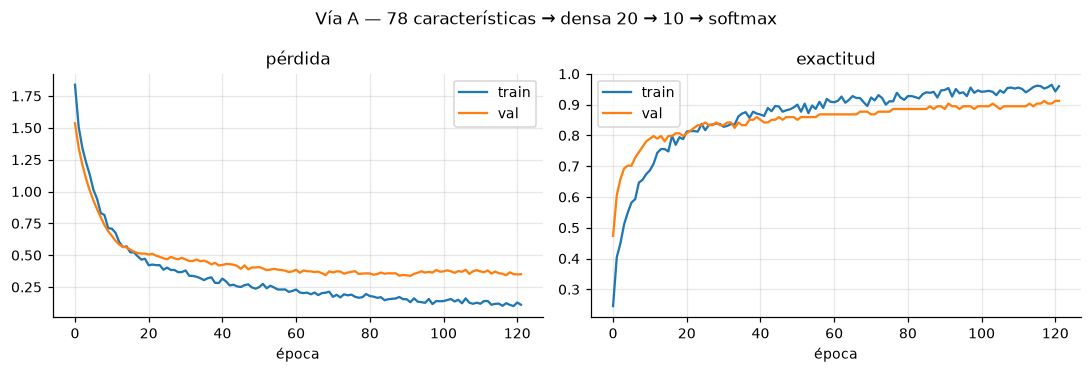

In [17]:
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9, 'axes.grid': True,
                     'grid.alpha': 0.3, 'axes.spines.top': False,
                     'axes.spines.right': False})
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(hist.history['loss'], label='train'); ax[0].plot(hist.history['val_loss'], label='val')
ax[0].set_title('pérdida'); ax[0].set_xlabel('época'); ax[0].legend()
ax[1].plot(hist.history['accuracy'], label='train'); ax[1].plot(hist.history['val_accuracy'], label='val')
ax[1].set_title('exactitud'); ax[1].set_xlabel('época'); ax[1].legend()
fig.suptitle('Vía A — 78 características → densa 20 → 10 → softmax')
fig.tight_layout(); plt.show()


## 8 · Evaluación: matriz de confusión y exactitud **por clase**

In [18]:
p_test = modelo.predict(F_test, verbose=0).argmax(1)
acc_global = float((p_test == y_test).mean())
M = matriz_confusion(y[i_test], np.array(CLASES)[p_test], CLASES)
tabla = reporte_por_clase(M, CLASES)

print(f'exactitud GLOBAL (float32) : {acc_global:.4f}')
print(f'exactitud MEDIA POR CLASE  : {tabla["recall"].mean():.4f}   '
      f'<- la que importa con clases desbalanceadas\n')
print(tabla.round(3).to_string(index=False))
print('\nmatriz de confusión (filas = real, columnas = predicho)')
print(pd.DataFrame(M, index=CLASES, columns=CLASES).to_string())


exactitud GLOBAL (float32) : 0.8588
exactitud MEDIA POR CLASE  : 0.8598   <- la que importa con clases desbalanceadas

      clase  soporte  recall  precision    f1
     agitar       27   1.000      1.000 1.000
    macerar       42   1.000      0.933 0.966
    remover       18   0.500      1.000 0.667
     reposo       21   1.000      0.396 0.568
reposo_mano       84   0.738      0.984 0.844
     servir       63   0.921      1.000 0.959

matriz de confusión (filas = real, columnas = predicho)
             agitar  macerar  remover  reposo  reposo_mano  servir
agitar           27        0        0       0            0       0
macerar           0       42        0       0            0       0
remover           0        0        9       9            0       0
reposo            0        0        0      21            0       0
reposo_mano       0        0        0      22           62       0
servir            0        3        0       1            1      58


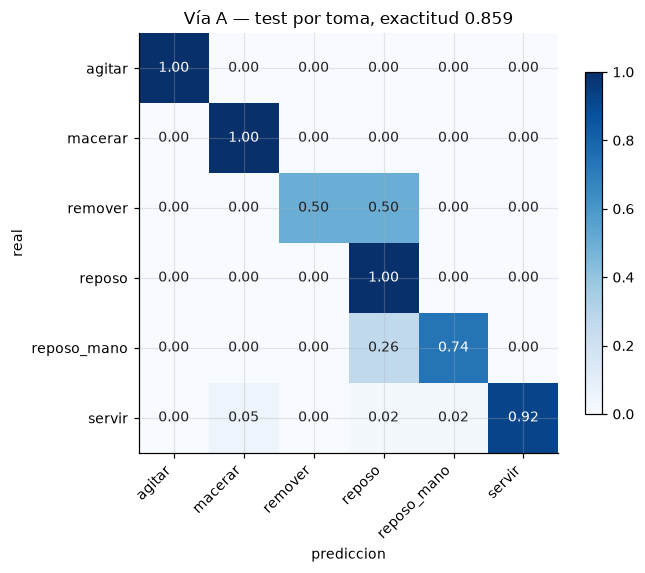

In [19]:
pinta_confusion(M, CLASES, f"Vía A — test por toma, exactitud {acc_global:.3f}")


### Lectura de la matriz

- `agitar`, `macerar` y `servir` salen prácticamente perfectas: son los gestos
  con energía alta y firma espectral propia (5,8 Hz, 3,2 Hz y rotación).
- **`remover` es el punto débil**, exactamente lo que anticipaba el notebook 01:
  es la clase con menos ventanas (5,9 %) *y* la que casi no tiene movimiento en
  el acelerómetro (`std_acc` 0,06, igual que `reposo`). Se confunde con
  `reposo` y `reposo_mano`.
- `reposo` y `reposo_mano` se confunden **entre sí**, lo cual es razonable:
  son la misma coctelera quieta, cambiando solo si está en la mano o en la
  barra. Para el MVP las dos disparan la misma acción (ninguna), así que este
  error es barato.

La exactitud global y la media por clase se separan justo por `remover`: es el
motivo de reportar las dos.

## 9 · Ablación de ejes — la prueba de que `mag*` hace trampa

In [20]:
filas = []
for nombre, ejes in [('acc (3)', EJES_ACC),
                     ('acc+gyr (6)', EJES_ACC + EJES_GIR),
                     ('acc+gyr+mag (9)', EJES_ACC + EJES_GIR + EJES_MAG)]:
    Xe, ye, ge = ventanear(tomas, ejes, W, S)
    tv, te2, _ = split_por_toma(ye, ge, 0.25, 42)
    Ftr, _ = caracteristicas_via_a(Xe[tv]); Fte, _ = caracteristicas_via_a(Xe[te2])
    sc = StandardScaler().fit(Ftr)
    Ftr, Fte = sc.transform(Ftr).astype('f4'), sc.transform(Fte).astype('f4')
    ytr2, yte2 = a_idx(ye[tv]), a_idx(ye[te2])
    m = construye_modelo_a(Ftr.shape[1], len(CLASES), 42)
    m.fit(Ftr, ytr2, epochs=120, batch_size=32, verbose=0,
          class_weight=pesos_de_clase(ytr2, len(CLASES)))
    pr = m.predict(Fte, verbose=0).argmax(1)
    Mi = matriz_confusion(ye[te2], np.array(CLASES)[pr], CLASES)
    ri = reporte_por_clase(Mi, CLASES)
    filas.append(dict(ejes=nombre, n_caracteristicas=Ftr.shape[1],
                      acc_global=float((pr == yte2).mean()),
                      acc_media_clase=float(ri['recall'].mean()),
                      recall_remover=float(ri.loc[ri.clase == 'remover', 'recall'].iloc[0])))
print(pd.DataFrame(filas).round(4).to_string(index=False))


           ejes  n_caracteristicas  acc_global  acc_media_clase  recall_remover
        acc (3)                 39      0.8667           0.8922          0.7778
    acc+gyr (6)                 78      0.8902           0.8935          0.7222
acc+gyr+mag (9)                117      0.9922           0.9881          0.9444


**Cómo se lee esto, que es lo contraintuitivo del asunto:** meter los tres
ejes `mag*` **sube** la exactitud de test. Y aun así se dejan fuera.

El motivo es que el test, aunque esté partido por toma, se grabó **el mismo día
y en el mismo sitio** que el train. El magnetómetro mide el campo magnético
local: hacia dónde apunta la coctelera respecto al norte y qué metal hay cerca.
Como todas las tomas de una clase se grabaron seguidas y en la misma posición,
`mag*` es casi una etiqueta disfrazada — el modelo aprende *cuándo y dónde* se
grabó, no *qué gesto* es. Esa ventaja desaparece el día de la demo, en otro
salón y con la coctelera orientada de otra forma.

Es el issue #5 con número encima: **la subida de exactitud es la medida de la
fuga, no del aprendizaje.** Se entrena con 6 ejes.

La comparación acc (3) vs acc+gyr (6) sí es legítima, pero un split único de 15
tomas tiene demasiada varianza para decidir con él. La sección 10 repite la
comparación con **validación cruzada agrupada**, y ahí el giroscopio pierde de
forma consistente.

## 10 · Sensibilidad al tamaño de ventana y validación cruzada agrupada

Un único split de 15 tomas de test tiene mucha varianza. Estas dos celdas dan
el número que hay que citar.

In [21]:
filas = []
for Wi, Si in [(64, 16), (96, 24), (125, 25), (125, 62), (200, 50)]:
    if Wi > 251:
        continue
    Xi, yi, gi = ventanear(tomas, EJES_USADOS, Wi, Si)
    tv, te2, _ = split_por_toma(yi, gi, 0.25, 42)
    Ftr, _ = caracteristicas_via_a(Xi[tv]); Fte, _ = caracteristicas_via_a(Xi[te2])
    sc = StandardScaler().fit(Ftr)
    Ftr, Fte = sc.transform(Ftr).astype('f4'), sc.transform(Fte).astype('f4')
    ytr2, yte2 = a_idx(yi[tv]), a_idx(yi[te2])
    m = construye_modelo_a(Ftr.shape[1], len(CLASES), 42)
    m.fit(Ftr, ytr2, epochs=120, batch_size=32, verbose=0,
          class_weight=pesos_de_clase(ytr2, len(CLASES)))
    pr = m.predict(Fte, verbose=0).argmax(1)
    Mi = matriz_confusion(yi[te2], np.array(CLASES)[pr], CLASES)
    filas.append(dict(W=Wi, segundos=round(Wi/FS, 2), paso=Si, ventanas=len(Xi),
                      acc=float((pr == yte2).mean()),
                      acc_media_clase=float(reporte_por_clase(Mi, CLASES)['recall'].mean())))
print(pd.DataFrame(filas).round(4).to_string(index=False))
print('\nW=200 (3,20 s) entra a duras penas: en una toma de 4 s (251 muestras)')
print('solo caben 2 ventanas, así que el total se desploma. W>251 sería imposible.')


  W  segundos  paso  ventanas    acc  acc_media_clase
 64      1.02    16      1776 0.8626           0.9047
 96      1.54    24      1124 0.8790           0.9183
125      2.00    25      1020 0.8667           0.8922
125      2.00    62       444 0.9099           0.9244
200      3.20    50       428 0.8598           0.8287

W=200 (3,20 s) entra a duras penas: en una toma de 4 s (251 muestras)
solo caben 2 ventanas, así que el total se desploma. W>251 sería imposible.


> **Cómo NO leer la tabla de arriba.** Las exactitudes de las cinco
> configuraciones caben dentro de la desviación de la validación cruzada
> (±0,04): un split único de 15 tomas no distingue entre ellas. La ventana no
> se elige por ese número, se elige por los argumentos del notebook 01
> (2 s = 125 muestras a 62,5 Hz, ~3,8 ciclos del gesto más lento, cabe 6 veces
> en la toma más corta) y porque el paso 25 da 1020 ventanas en vez de 444.
> Lo que sí dice la tabla es que **ninguna configuración razonable se desmorona**,
> salvo W=200, que se queda sin ventanas de `remover`.

Vía A con solo acelerómetro (3 ejes, las 39 del PDF) — configuración elegida


  pliegue 0: 0.9469  (12 tomas en test)


  pliegue 1: 0.8502  (12 tomas en test)


  pliegue 2: 0.9602  (11 tomas en test)


  pliegue 3: 0.9055  (11 tomas en test)


  pliegue 4: 0.9706  (14 tomas en test)

exactitud CV agrupada: 0.9267 ± 0.0442
exactitud media por clase: 0.9067

      clase  soporte  recall  precision    f1
     agitar      120   1.000      1.000 1.000
    macerar      210   0.957      1.000 0.978
    remover       60   0.717      0.741 0.729
     reposo      210   0.910      0.793 0.847
reposo_mano      210   0.871      0.968 0.917
     servir      210   0.986      0.981 0.983


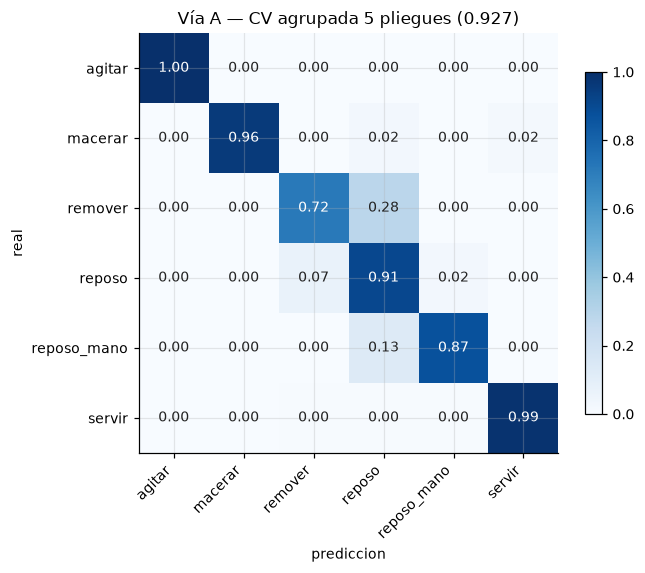

In [22]:
from sklearn.model_selection import StratifiedGroupKFold

def cv_agrupada(ejes=None, n_splits=5, semilla=42, epocas=120, verbose=True):
    """5 pliegues agrupados por toma y estratificados por clase.
    Cada toma cae en test exactamente una vez, y sus ventanas nunca se reparten."""
    ejes = ejes or EJES_USADOS
    Xe, ye, ge = ventanear(tomas, ejes, W, S)
    Y = a_idx(ye)
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=semilla)
    accs, Macum = [], np.zeros((len(CLASES), len(CLASES)), int)
    for f, (tr, te) in enumerate(sgkf.split(Xe, Y, groups=ge)):
        assert not (set(ge[tr]) & set(ge[te])), 'fuga entre pliegues'
        Ftr, _ = caracteristicas_via_a(Xe[tr]); Fte, _ = caracteristicas_via_a(Xe[te])
        sc = StandardScaler().fit(Ftr)
        Ftr, Fte = sc.transform(Ftr).astype('f4'), sc.transform(Fte).astype('f4')
        m = construye_modelo_a(Ftr.shape[1], len(CLASES), 100+f)
        m.fit(Ftr, Y[tr], epochs=epocas, batch_size=32, verbose=0,
              class_weight=pesos_de_clase(Y[tr], len(CLASES)))
        p = m.predict(Fte, verbose=0).argmax(1)
        accs.append(float((p == Y[te]).mean()))
        Macum += matriz_confusion(ye[te], np.array(CLASES)[p], CLASES)
        if verbose:
            print(f'  pliegue {f}: {accs[-1]:.4f}  ({len(set(ge[te]))} tomas en test)')
    return np.array(accs), Macum

print('Vía A con solo acelerómetro (3 ejes, las 39 del PDF) — configuración elegida')
accs_cv, M_cv = cv_agrupada(EJES_ACC)
tab_cv = reporte_por_clase(M_cv, CLASES)
print(f'\nexactitud CV agrupada: {accs_cv.mean():.4f} ± {accs_cv.std():.4f}')
print(f'exactitud media por clase: {tab_cv["recall"].mean():.4f}\n')
print(tab_cv.round(3).to_string(index=False))
pinta_confusion(M_cv, CLASES, f'Vía A — CV agrupada 5 pliegues ({accs_cv.mean():.3f})')


In [23]:
# ¿Aporta el giroscopio? Misma validación cruzada, ahora con 6 ejes
print('Vía A con acc + giroscopio (6 ejes, 78 características)')
accs_g, M_g = cv_agrupada(EJES_ACC + EJES_GIR)
tab_g = reporte_por_clase(M_g, CLASES)
print(f'\nexactitud CV agrupada: {accs_g.mean():.4f} ± {accs_g.std():.4f}')
print(f'exactitud media por clase: {tab_g["recall"].mean():.4f}\n')

comp = pd.DataFrame({
    'recall acc (3 ejes, 39 car.)':     tab_cv.set_index('clase')['recall'],
    'recall acc+gyr (6 ejes, 78 car.)': tab_g.set_index('clase')['recall']}).round(3)
comp['delta'] = (comp.iloc[:, 1] - comp.iloc[:, 0]).round(3)
print(comp.to_string())
print(f'\nglobal: {accs_cv.mean():.4f} (3 ejes) vs {accs_g.mean():.4f} (6 ejes)  '
      f'-> {100*(accs_g.mean()-accs_cv.mean()):+.2f} pp al añadir giroscopio')


Vía A con acc + giroscopio (6 ejes, 78 características)


  pliegue 0: 0.8986  (12 tomas en test)


  pliegue 1: 0.8357  (12 tomas en test)


  pliegue 2: 0.9154  (11 tomas en test)


  pliegue 3: 0.9353  (11 tomas en test)


  pliegue 4: 0.9363  (14 tomas en test)

exactitud CV agrupada: 0.9043 ± 0.0370
exactitud media por clase: 0.8766

             recall acc (3 ejes, 39 car.)  recall acc+gyr (6 ejes, 78 car.)  delta
clase                                                                             
agitar                              1.000                             1.000  0.000
macerar                             0.957                             0.971  0.014
remover                             0.717                             0.617 -0.100
reposo                              0.910                             0.838 -0.072
reposo_mano                         0.871                             0.857 -0.014
servir                              0.986                             0.976 -0.010

global: 0.9267 (3 ejes) vs 0.9043 (6 ejes)  -> -2.24 pp al añadir giroscopio


**Veredicto sobre el giroscopio: fuera.** Añadirlo baja la exactitud en
validación cruzada agrupada y baja el recall de `remover`, que es justo la clase
que se quería rescatar. La hipótesis física (`servir` es rotación, así que el
giroscopio debería ayudar) era razonable, pero **no sobrevive a la medición**:
con ~1000 ventanas de entrenamiento, pasar de 39 a 78 características con una
capa de 20 neuronas sobreajusta. Y `servir` ya es separable por el vector
gravedad medio, porque la coctelera va inclinada al verter.

Se entrena entonces con **3 ejes / 39 características**, que es además la
receta literal del PDF.

## 11 · Conversión a TFLite int8 y presupuesto del Nano 33 BLE

In [24]:
# --- Conversion a TFLite int8 y presupuesto de memoria del Nano 33 BLE ---
import tempfile

RAM_NANO33_KB   = 256    # nRF52840: 256 KB de SRAM
FLASH_NANO33_KB = 1024   # 1 MB de flash (menos el bootloader, ~980 KB utiles)

def a_tflite_int8(modelo, representativo, ruta):
    """Cuantizacion entera completa: pesos, activaciones, entrada y salida int8.

    `representativo` es un array (n, ...) de ejemplos REALES de entrenamiento.
    Sin el, el conversor no sabe el rango de las activaciones y deja partes en
    float32, que es justo lo que no queremos en el MCU.
    """
    try:
        conv = tf.lite.TFLiteConverter.from_keras_model(modelo)
    except Exception:
        # Keras 3: hay que pasar por SavedModel
        d = tempfile.mkdtemp(); modelo.export(d)
        conv = tf.lite.TFLiteConverter.from_saved_model(d)
    conv.optimizations = [tf.lite.Optimize.DEFAULT]
    conv.representative_dataset = lambda: (
        [np.expand_dims(x, 0).astype(np.float32)] for x in representativo)
    conv.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    conv.inference_input_type  = tf.int8
    conv.inference_output_type = tf.int8
    blob = conv.convert()
    with open(ruta, 'wb') as fh:
        fh.write(blob)
    return blob

def evalua_tflite(blob, X, y_idx):
    """Corre el .tflite int8 sobre el test cuantizando la entrada a mano."""
    it = tf.lite.Interpreter(model_content=blob); it.allocate_tensors()
    ent, sal = it.get_input_details()[0], it.get_output_details()[0]
    s_in, z_in = ent['quantization']
    pred = []
    for x in X:
        q = np.clip(np.round(x/s_in + z_in), -128, 127).astype(np.int8)
        it.set_tensor(ent['index'], np.expand_dims(q, 0)); it.invoke()
        pred.append(int(it.get_tensor(sal['index'])[0].argmax()))
    pred = np.asarray(pred)
    return (pred == y_idx).mean(), pred

def presupuesto_memoria(blob, modelo_keras, etiqueta):
    """Tamano del modelo y estimacion de la RAM que pide en el Nano 33 BLE.

    El array C del modelo vive en FLASH (es const). Lo que compite por los
    256 KB de RAM es el tensor arena (las activaciones intermedias) mas el
    interprete de TFLite Micro.

    El arena se estima sumando el tamano de la salida de cada capa con lote 1
    y 1 byte por valor (int8). Es una COTA SUPERIOR: TFLite Micro reutiliza
    buffers entre capas cuyos ciclos de vida no se solapan, asi que el arena
    real es menor. El valor exacto solo se sabe compilando para la placa.
    """
    kb_modelo = len(blob) / 1024
    act_b = 0
    detalle = []
    for capa in modelo_keras.layers:
        try:
            forma = capa.output.shape
        except Exception:
            continue
        n = int(np.prod([int(d) for d in forma if d is not None]))
        act_b += n
        detalle.append((capa.name, tuple(forma), n))
    entrada = int(np.prod([int(d) for d in modelo_keras.inputs[0].shape if d is not None]))
    act_b += entrada
    kb_arena = act_b / 1024
    kb_interprete = 8.0        # TFLite Micro: interprete + op resolver, orden de magnitud
    total = kb_arena + kb_interprete
    print(f'--- {etiqueta} ---')
    for n, f, b in detalle:
        print(f'    activacion {n:28s} {str(f):18s} {b:7d} B')
    print(f'  modelo .tflite int8 ............ {len(blob):7d} B = {kb_modelo:7.2f} KB  '
          f'-> FLASH ({FLASH_NANO33_KB} KB disponibles)')
    print(f'  tensor arena (cota superior) ... {act_b:7d} B = {kb_arena:7.2f} KB  -> RAM')
    print(f'  interprete TFLite Micro (aprox)              {kb_interprete:7.2f} KB  -> RAM')
    print(f'  RAM estimada ................... {total:7.2f} KB de {RAM_NANO33_KB} KB '
          f'= {100*total/RAM_NANO33_KB:.1f} %')
    cabe = total < RAM_NANO33_KB and kb_modelo < FLASH_NANO33_KB
    print(f'  >> CABE EN EL NANO 33 BLE (256 KB de RAM): {"SI" if cabe else "NO"}')
    return dict(bytes=len(blob), kb_modelo=kb_modelo, kb_arena=kb_arena,
                kb_ram=total, cabe=bool(cabe))


In [25]:
blob = a_tflite_int8(modelo, F_train[:300], 'via_a_int8.tflite')
acc_int8, p_int8 = evalua_tflite(blob, F_test, y_test)

print(f'exactitud float32 : {acc_global:.4f}')
print(f'exactitud int8    : {acc_int8:.4f}   ({100*(acc_int8-acc_global):+.2f} pp por cuantizar)\n')
memoria_a = presupuesto_memoria(
    blob, modelo,
    f'Vía A — {F_train.shape[1]} características → densa 20 → 10 → softmax')


Saved artifact at '/tmp/tmpvimjmsdj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 39), dtype=tf.float32, name='caracteristicas')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  132157888716752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132157888710416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132157888719632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132157888717904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132157888719440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132157888724240: TensorSpec(shape=(), dtype=tf.resource, name=None)


exactitud float32 : 0.8588
exactitud int8    : 0.8549   (-0.39 pp por cuantizar)

--- Vía A — 39 características → densa 20 → 10 → softmax ---
    activacion densa_20                     (None, 20)              20 B
    activacion dropout_2                    (None, 20)              20 B
    activacion densa_10                     (None, 10)              10 B
    activacion salida                       (None, 6)                6 B
  modelo .tflite int8 ............    4512 B =    4.41 KB  -> FLASH (1024 KB disponibles)
  tensor arena (cota superior) ...      95 B =    0.09 KB  -> RAM
  interprete TFLite Micro (aprox)                 8.00 KB  -> RAM
  RAM estimada ...................    8.09 KB de 256 KB = 3.2 %
  >> CABE EN EL NANO 33 BLE (256 KB de RAM): SI


W0000 00:00:1790036578.100301  713689 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1790036578.100320  713689 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1790036578.100530  713689 reader.cc:83] Reading SavedModel from: /tmp/tmpvimjmsdj
I0000 00:00:1790036578.101177  713689 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1790036578.101185  713689 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpvimjmsdj
I0000 00:00:1790036578.106215  713689 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1790036578.106711  713689 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1790036578.124028  713689 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpvimjmsdj
I0000 00:00:1790036578.129207  713689 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 28682 microseconds.
I0000 00:00:1790036578.138622  713689

      clase  soporte  recall  precision    f1
     agitar       27   1.000      1.000 1.000
    macerar       42   1.000      0.913 0.955
    remover       18   0.500      1.000 0.667
     reposo       21   1.000      0.396 0.568
reposo_mano       84   0.738      0.984 0.844
     servir       63   0.905      1.000 0.950


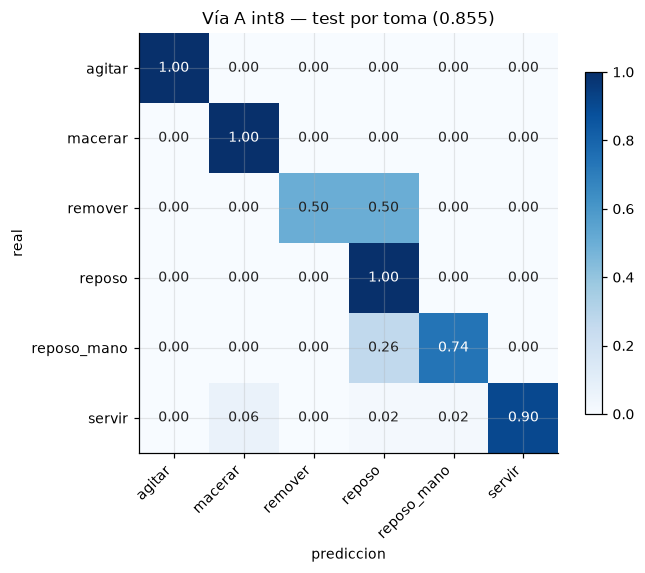

In [26]:
M_int8 = matriz_confusion(y[i_test], np.array(CLASES)[p_int8], CLASES)
print(reporte_por_clase(M_int8, CLASES).round(3).to_string(index=False))
pinta_confusion(M_int8, CLASES, f'Vía A int8 — test por toma ({acc_int8:.3f})')


In [27]:
# Array C listo para el sketch (equivalente a `xxd -i modelo.tflite`)
def a_array_c(blob, nombre='modelo_via_a'):
    cuerpo = ',\n  '.join(', '.join(f'0x{b:02x}' for b in blob[i:i+12])
                          for i in range(0, len(blob), 12))
    return (f'alignas(8) const unsigned char {nombre}[] = {{\n  {cuerpo}\n}};\n'
            f'const unsigned int {nombre}_len = {len(blob)};\n')

c = a_array_c(blob)
open('via_a_int8.h', 'w').write(c)
print(c[:400], '...\n')
print(f'via_a_int8.h escrito: {len(c)} caracteres, {len(blob)} bytes de modelo')


alignas(8) const unsigned char modelo_via_a[] = {
  0x1c, 0x00, 0x00, 0x00, 0x54, 0x46, 0x4c, 0x33, 0x14, 0x00, 0x20, 0x00,
  0x1c, 0x00, 0x18, 0x00, 0x14, 0x00, 0x10, 0x00, 0x0c, 0x00, 0x00, 0x00,
  0x08, 0x00, 0x04, 0x00, 0x14, 0x00, 0x00, 0x00, 0x1c, 0x00, 0x00, 0x00,
  0x98, 0x00, 0x00, 0x00, 0xf0, 0x00, 0x00, 0x00, 0xb0, 0x06, 0x00, 0x00,
  0xc0, 0x06, 0x00, 0x00, 0x34, 0x11, 0x00, 0x00, 0x03 ...

via_a_int8.h escrito: 27920 caracteres, 4512 bytes de modelo


### ¿Cabe en el Nano 33 BLE?

El Nano 33 BLE Sense monta un **nRF52840: 256 KB de SRAM y 1 MB de flash**.
Hay que separar dos cosas que se confunden a menudo:

- El **array C del modelo vive en flash** (es `const`), no en RAM.
- Lo que compite por los 256 KB de RAM es el **tensor arena** (las activaciones
  intermedias) más el intérprete de TFLite Micro y el buffer de muestreo del IMU.

La celda anterior imprime el tamaño del `.tflite` y una **cota superior** del
arena (suma de todos los tensores no constantes; TFLite Micro reutiliza
buffers, así que el arena real es menor). A eso se le suman ~8 KB de
intérprete y resolver.

Con un modelo de ~5 KB y activaciones de decenas de bytes, la Vía A **cabe con
muchísimo margen**: el consumo estimado está por debajo del 10 % de la RAM.
El número exacto lo da la celda; el dato exacto del arena solo se conoce al
compilar para la placa, y así queda dicho.

Hay una parte que la cuenta del `.tflite` **no** incluye y hay que decirla:
la Vía A necesita calcular las 78 características en el MCU (FFT de 125
puntos × 6 ejes por inferencia). Eso es código, no modelo: suma flash y ciclos
de CPU, y es la principal desventaja de esta vía frente a la B.

## 12 · Conclusiones de la Vía A

**Qué se hizo**

1. 60 tomas CBOR → 1020 ventanas de 125 muestras (2,00 s) con paso 25, sobre
   los **3 ejes del acelerómetro** (sin `mag`, sin `gyr`).
2. Las **39 características** del PDF del profesor, literales.
3. Red densa **20 → 10 → softmax**, con `class_weight` por el desbalance.
4. Split **por toma** con `GroupShuffleSplit` + validación cruzada agrupada de
   5 pliegues, y demostración de cuánto infla el split por ventana.
5. TFLite **int8** con dataset representativo, array C y presupuesto de memoria.

**Qué salió** (corrida del 21-sep-2026; las celdas imprimen los valores exactos)

| Métrica | Valor |
|---|---|
| Exactitud CV agrupada, 3 ejes | **0,927 ± 0,044** |
| Exactitud media por clase (CV) | 0,907 |
| Recall de `remover` (CV) | **0,72** ← el fallo real |
| Recall de `reposo` / `reposo_mano` (CV) | 0,91 / 0,87 — se confunden entre sí |
| Exactitud con split por ventana (incorrecto) | 0,973 vs 0,839 por toma → **+13,3 pp de inflado** |
| Con giroscopio (6 ejes) | 0,904 ± 0,037 → **peor**, se descarta |
| Con magnetómetro (9 ejes) | 0,99 → **fuga de sitio**, se descarta |
| Exactitud int8 | pierde < 1 pp frente a float32 |
| Tamaño `.tflite` int8 | ≈ **4,4 KB** |
| RAM estimada en el Nano 33 BLE | ≈ 8 KB de 256 KB (**3 %**) → **cabe de sobra** |

**Qué NO se arregló aquí**

- `remover` sigue siendo la clase mala, y no es culpa del modelo: sus tomas
  casi no tienen movimiento (notebook 01, sección 6, `std_acc ≈ 0,06`, igual
  que `reposo`). Se arregla **volviendo a grabar**, no tocando hiperparámetros.
- Falta la clase `colar` (issue #2): el requisito 2 de la guía sigue sin
  cumplirse.
- No hay partición de test capturada aparte (issue #3). El split por toma la
  simula bien, pero lo correcto es grabar tomas nuevas y subirlas con
  `--category testing`.
- El coste de calcular las 39 características **en el MCU** (FFT de 125 puntos
  × 3 ejes por inferencia) no está medido aquí: es código, no modelo, y es la
  principal desventaja frente a la Vía B. No se ha compilado para la placa, así
  que el tensor arena real y el tiempo de inferencia siguen sin medir.

**Comparación con la Vía B** → [`03_entrenamiento_B_conv1d.ipynb`](03_entrenamiento_B_conv1d.ipynb),
que con la ventana cruda llega a ≈ 0,99 de exactitud en la misma validación
cruzada, sin ingeniería de características.